# GLOFAS-based Hydro Inflow Time Series

This notebook demonstrates how to use atlite's GLOFAS (Global Flood Awareness System) dataset to extract discharge-based inflow time series for hydroelectric plants.

## Overview

atlite supports two methods for computing hydroelectric plant inflow:

1. **ERA5-based (runoff)**: Aggregates ERA5 runoff data over catchment basins using HydroBASINS
2. **GLOFAS-based (discharge)**: Uses direct river discharge data by snapping plants to nearest grid cells

GLOFAS provides daily river discharge estimates at ~0.1° spatial resolution from reanalysis data, making it ideal for large-scale hydropower studies with minimal preprocessing.

<!--
SPDX-FileCopyrightText: Contributors to atlite <https://github.com/pypsa/atlite>

SPDX-License-Identifier: MIT
-->

## Setup and Requirements

Ensure you have the necessary dependencies installed and CDS API credentials configured. The Copernicus Climate Data Store (CDS) API is required to download GLOFAS data.

For setup instructions, see the [CDS API documentation](https://cds.climate.copernicus.eu/how-to-api).

In [37]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

import atlite

# Setup logging to monitor progress
logging.basicConfig(level=logging.INFO)

print(f"atlite version: {atlite.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"xarray version: {xr.__version__}")

atlite version: 0.6.1.post1.dev26+gfcbb57a2f.d20260812
pandas version: 3.0.3
xarray version: 2026.7.0


## Create and Prepare a Cutout

We start by defining a geographic region of interest and creating a cutout. The cutout specifies:

- **module**: Data source (`glofas` for discharge data)
- **x, y**: Longitude and latitude bounds of your region
- **time**: Time period to cover
- **path**: Local storage location for the cutout

If the cutout already exists at the specified path, it will be loaded. Otherwise, a new one is created and prepared on demand.

In [38]:
# Define region of interest: Scandinavia
# Bounds: (west, south, east, north) in degrees longitude/latitude
cutout = atlite.Cutout(
    path="scandinavia-glofas",
    module="glofas",
    x=slice(0, 40),  # longitude: 0°E to 40°E
    y=slice(55, 72),  # latitude: 55°N to 72°N
    time="2020",  # full year 2020
    data_source="cems-glofas-historical",
)

print("Cutout bounds:")
print(
    f"  Longitude: {cutout.coords['x'].values[0]:.2f}° to {cutout.coords['x'].values[-1]:.2f}°"
)
print(
    f"  Latitude: {cutout.coords['y'].values[0]:.2f}° to {cutout.coords['y'].values[-1]:.2f}°"
)
print(
    f"  Time: {cutout.coords['time'].values[0]} to {cutout.coords['time'].values[-1]}"
)

Cutout bounds:
  Longitude: 0.00° to 40.00°
  Latitude: 55.00° to 72.00°
  Time: 2020-01-01T00:00:00.000000000 to 2020-12-31T23:00:00.000000000


/tmp/ipykernel_3927823/4188880446.py:3: UserWarning: Arguments module, x, y, time, data_source are ignored, since cutout is already built.
  cutout = atlite.Cutout(


### Prepare the Cutout Data

The `prepare()` method downloads and processes the GLOFAS discharge data for the specified region and time period. This is where the actual data retrieval happens from the CDS servers.

> **Note**: Depending on the size of your cutout, this step may take several minutes. The data is cached locally and subsequent calls will be much faster.

In [39]:
# Download and prepare GLOFAS discharge data
cutout.prepare()

# Display available data
print("\nPrepared data in cutout:")
print(f"  Available variables: {list(cutout.data.data_vars)}")
print(f"  Spatial resolution: {cutout.data.discharge.shape[1:]}")
print(f"  Time steps: {len(cutout.data.time)}")

# Check discharge data statistics
discharge = cutout.data.discharge
print("\nDischarge data statistics (m³/s):")
print(f"  Min: {float(discharge.min()):.2f}")
print(f"  Mean: {float(discharge.mean()):.2f}")
print(f"  Max: {float(discharge.max()):.2f}")
print(f"  Std: {float(discharge.std()):.2f}")

INFO:atlite.data:Storing temporary files in /tmp/tmpqot6xhhs



Prepared data in cutout:
  Available variables: ['discharge']
  Spatial resolution: (409, 961)
  Time steps: 8784

Discharge data statistics (m³/s):
  Min: 0.00
  Mean: 6.88
  Max: 28079.62
  Std: 66.02


## Prepare Hydroelectric Plant Data

Define your hydroelectric plants as a pandas DataFrame. The minimum required columns are:
- `lon`: Longitude of the plant location
- `lat`: Latitude of the plant location

Additional columns (capacity, type, etc.) are optional and useful for analysis.

In [40]:
# Create a sample hydroelectric plant dataset
# In practice, you would load this from a real dataset or database
plants = pd.DataFrame(
    {
        "name": [
            "Scandinavian Plant A",
            "Scandinavian Plant B",
            "Scandinavian Plant C",
            "Scandinavian Plant D",
        ],
        "lon": [10.5, 15.2, 20.1, 25.8],
        "lat": [60.2, 61.5, 59.8, 63.1],
        "capacity_mw": [50, 100, 75, 150],
        "type": ["run-of-river", "reservoir", "run-of-river", "reservoir"],
    },
    index=pd.Index(["plant_a", "plant_b", "plant_c", "plant_d"], name="plant"),
)

print("Hydroelectric Plants:")
print(plants)
print(f"\nTotal installed capacity: {plants['capacity_mw'].sum()} MW")

Hydroelectric Plants:
                         name   lon   lat  capacity_mw          type
plant                                                               
plant_a  Scandinavian Plant A  10.5  60.2           50  run-of-river
plant_b  Scandinavian Plant B  15.2  61.5          100     reservoir
plant_c  Scandinavian Plant C  20.1  59.8           75  run-of-river
plant_d  Scandinavian Plant D  25.8  63.1          150     reservoir

Total installed capacity: 375 MW


## Extract GLOFAS-based Inflow Time Series

The `cutout.hydro()` method extracts discharge-based inflow by snapping each plant to the nearest GLOFAS grid cell with discharge data. This approach:

- Requires no catchment basin delineation (unlike ERA5 runoff approach)
- Uses actual river discharge measurements/reanalysis
- Is computationally efficient
- Works globally at ~0.1° resolution

> **Note**: Plants located outside active river networks (e.g., on hillsides or in sparsely gauged regions) will show zero or near-zero discharge values. This is a realistic limitation of point-snapping approaches.

In [41]:
# Extract GLOFAS-based discharge inflow time series for each plant
inflow = cutout.hydro(
    plants=plants,
    module="glofas",  # Use GLOFAS discharge data
)

print(f"Inflow data shape: {inflow.shape}")
print(f"Coordinates: {list(inflow.coords.keys())}")
print(f"\nData type: {type(inflow)}")
print("\nFirst values (m³/s):")
print(inflow.isel(time=slice(0, 5)).values)

Inflow data shape: (4, 8784)
Coordinates: ['x', 'y', 'lon', 'lat', 'surface', 'plant', 'time']

Data type: <class 'xarray.core.dataarray.DataArray'>

First values (m³/s):
[[0.1875     0.1875     0.1875     0.1875     0.1875    ]
 [0.15625    0.15690104 0.15755208 0.15820312 0.15885417]
 [0.         0.         0.         0.         0.        ]
 [0.5625     0.56575521 0.56901042 0.57226562 0.57552083]]


## Analyze Inflow Time Series

Now let's analyze the extracted discharge time series to understand the hydrological characteristics at each plant location.

In [42]:
# Convert to DataFrame for easier analysis
inflow_df = inflow.to_pandas().T

print("Inflow Statistics (m³/s):")
print("=" * 60)
stats = inflow_df.describe().T
stats = stats[["mean", "std", "min", "25%", "50%", "75%", "max"]]
print(stats.round(2))

Inflow Statistics (m³/s):
         mean   std   min   25%   50%   75%   max
plant                                            
plant_a  0.36  0.20  0.15  0.23  0.29  0.41  1.25
plant_b  0.15  0.04  0.11  0.12  0.13  0.16  0.38
plant_c  0.00  0.00  0.00  0.00  0.00  0.00  0.00
plant_d  1.04  0.32  0.55  0.78  0.99  1.23  2.06


### Monthly Aggregation

Let's aggregate the daily discharge data to monthly averages to understand seasonal patterns.

In [ ]:
# Aggregate to monthly averages
inflow_monthly = inflow.resample(time="ME").mean()

# Create summary table
monthly_stats = inflow_monthly.to_pandas().T
print("\nMonthly Average Discharge (m³/s):")
print("=" * 60)
print(monthly_stats.round(2))

# Calculate seasonal patterns
print("\nSeasonal Statistics (m³/s):")
print("=" * 60)
seasonal = inflow.resample(time="QS").mean()
seasons = ["Winter (Q1)", "Spring (Q2)", "Summer (Q3)", "Fall (Q4)"]
for season, discharge in zip(seasons, seasonal.values, strict=False):
    print(f"{season:20s} {discharge}")

## Visualization

Visualize the temporal patterns and characteristics of the discharge data across plants.

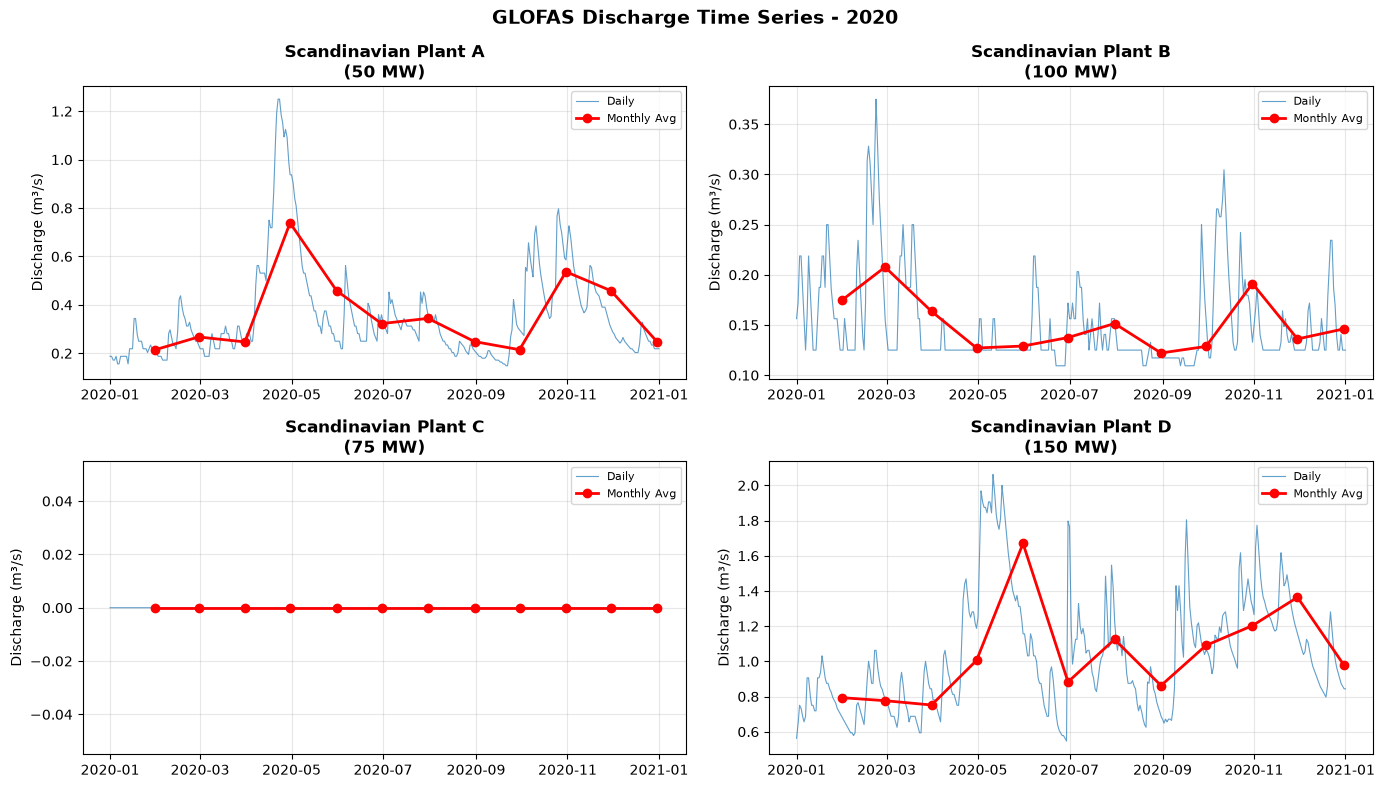

Discharge time series plotted for all plants.


In [44]:
# Plot time series for all plants
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, plant_id in enumerate(plants.index):
    ax = axes[idx]
    plant_inflow = inflow.sel(plant=plant_id)

    # Plot daily discharge
    ax.plot(
        plant_inflow.time.values,
        plant_inflow.values,
        linewidth=0.8,
        alpha=0.7,
        label="Daily",
    )

    # Overlay monthly average
    monthly = plant_inflow.resample(time="ME").mean()
    ax.plot(
        monthly.time.values,
        monthly.values,
        linewidth=2,
        color="red",
        label="Monthly Avg",
        marker="o",
    )

    plant_name = plants.loc[plant_id, "name"]
    plant_capacity = plants.loc[plant_id, "capacity_mw"]

    ax.set_title(f"{plant_name}\n({plant_capacity} MW)", fontweight="bold")
    ax.set_ylabel("Discharge (m³/s)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)

fig.suptitle("GLOFAS Discharge Time Series - 2020", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Discharge time series plotted for all plants.")

### Box Plot Comparison

Compare the distribution of discharge across plants using box plots.

In [ ]:
# Prepare data for box plot
plot_data = []
labels = []

for plant_id in plants.index:
    plant_inflow = inflow.sel(plant=plant_id).values
    plot_data.append(plant_inflow)
    plant_name = plants.loc[plant_id, "name"]
    labels.append(f"{plant_name}\n({plants.loc[plant_id, 'capacity_mw']} MW)")

# Create box plot
fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(plot_data, patch_artist=True)

# Set labels
ax.set_xticklabels(labels)

# Customize colors
colors = ["lightblue", "lightgreen", "lightyellow", "lightcoral"]
for patch, color in zip(bp["boxes"], colors, strict=False):
    patch.set_facecolor(color)

ax.set_ylabel("Discharge (m³/s)", fontsize=11)
ax.set_title(
    "Distribution of GLOFAS Discharge by Plant (2020)", fontsize=12, fontweight="bold"
)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("Box plot comparison complete.")

Correlation Matrix of Discharge Between Plants:
plant    plant_a  plant_b  plant_c  plant_d
plant                                      
plant_a    1.000    0.065      NaN    0.481
plant_b    0.065    1.000      NaN   -0.021
plant_c      NaN      NaN      NaN      NaN
plant_d    0.481   -0.021      NaN    1.000


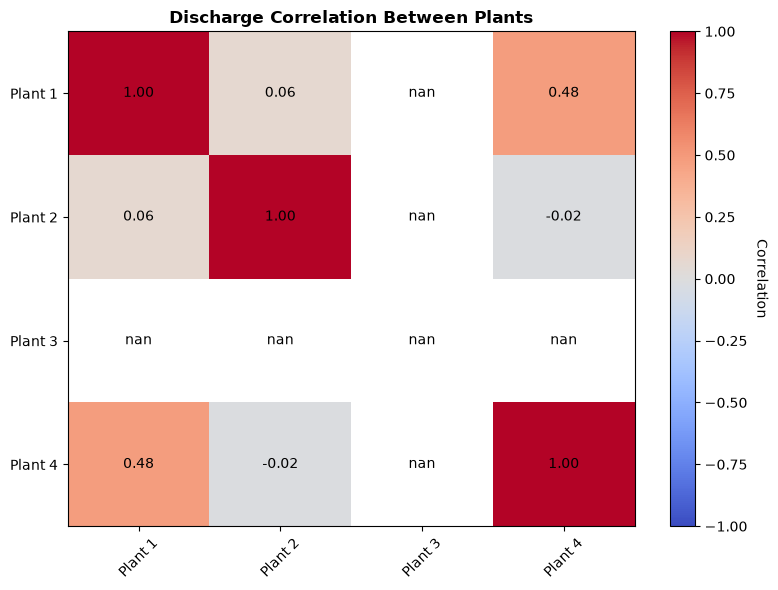


Correlation analysis: Plants with high correlation share similar
hydrological patterns, suggesting they may be in the same river basin.


In [46]:
# Calculate correlation matrix
inflow_corr = inflow_df.corr()

print("Correlation Matrix of Discharge Between Plants:")
print("=" * 60)
print(inflow_corr.round(3))

# Visualize correlation
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(inflow_corr.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")

# Set labels
ax.set_xticks(range(len(plants)))
ax.set_yticks(range(len(plants)))
plant_labels = [f"Plant {i + 1}" for i in range(len(plants))]
ax.set_xticklabels(plant_labels, rotation=45)
ax.set_yticklabels(plant_labels)

# Add correlation values as text
for i in range(len(plants)):
    for j in range(len(plants)):
        text = ax.text(
            j,
            i,
            f"{inflow_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=10,
        )

ax.set_title("Discharge Correlation Between Plants", fontweight="bold")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Correlation", rotation=270, labelpad=15)
plt.tight_layout()
plt.show()

print("\nCorrelation analysis: Plants with high correlation share similar")
print("hydrological patterns, suggesting they may be in the same river basin.")

In [47]:
# Create output directory
output_dir = Path("glofas_inflow_output")
output_dir.mkdir(exist_ok=True)

# Export as NetCDF (preserves all metadata and structure)
inflow.to_netcdf(output_dir / "glofas_inflow_2020.nc")
print(f"✓ Saved NetCDF: {output_dir / 'glofas_inflow_2020.nc'}")

# Export as CSV for spreadsheet analysis
inflow_df.to_csv(output_dir / "glofas_inflow_2020.csv")
print(f"✓ Saved CSV: {output_dir / 'glofas_inflow_2020.csv'}")

# Export monthly aggregates
monthly_stats.to_csv(output_dir / "glofas_inflow_monthly_2020.csv")
print(f"✓ Saved monthly stats: {output_dir / 'glofas_inflow_monthly_2020.csv'}")

# Save plant metadata
plants.to_csv(output_dir / "plants.csv")
print(f"✓ Saved plant metadata: {output_dir / 'plants.csv'}")

print(f"\nAll results exported to: {output_dir.absolute()}")

✓ Saved NetCDF: glofas_inflow_output/glofas_inflow_2020.nc
✓ Saved CSV: glofas_inflow_output/glofas_inflow_2020.csv
✓ Saved monthly stats: glofas_inflow_output/glofas_inflow_monthly_2020.csv
✓ Saved plant metadata: glofas_inflow_output/plants.csv

All results exported to: /home/fabian/vres/py/worktrees/atlite/solar-violet/atlite/examples/glofas_inflow_output


## Export Results

Save the extracted inflow time series in NetCDF format for further analysis or integration with other tools.

In [ ]:
# Create output directory
output_dir = Path("glofas_inflow_output")
output_dir.mkdir(exist_ok=True)

# Export as NetCDF (preserves all metadata and structure)
inflow.to_netcdf(output_dir / "glofas_inflow_2020.nc")
print(f"✓ Saved NetCDF: {output_dir / 'glofas_inflow_2020.nc'}")

# Save plant metadata
plants.to_csv(output_dir / "plants.csv")
print(f"✓ Saved plant metadata: {output_dir / 'plants.csv'}")

print(f"\nAll results exported to: {output_dir.absolute()}")

## Energy Calculations

Estimate potential hydroelectric energy generation based on discharge and plant capacity. This is a simplified example; actual calculations would account for plant efficiency, head loss, and other factors.